# Split the Dataset (Train/Test)

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.utils import shuffle

# Load shuffeled dataset
df = pd.read_csv("../preprocessing/ready/squat_dataset.csv")

# Shuffle the DataFrame
df = shuffle(df, random_state=42).reset_index(drop=True)

# Select correct features based on your dataset
feature_cols = [col for col in df.columns if col != "label"]

# Separate features and labels
X = df[feature_cols]
y = df["label"]

# Split into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f" Training labels: {len(y_train)}, Test labels: {len(y_test)}")

 Training samples: 157, Test samples: 40
 Training labels: 157, Test labels: 40


# Nested Cross-Validation with Best Parameters Logging

In [3]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize the base model
rf = RandomForestClassifier(random_state=42)

# Outer loop: Stratified K-Fold for evaluation
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores and best parameters
cv_scores = []
best_params_list = []

# Perform nested cross-validation manually
for train_idx, val_idx in cv_outer.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Inner loop: Grid Search CV
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train_fold, y_train_fold)

    # Get best model and evaluate on validation set
    best_model = grid_search.best_estimator_
    val_score = best_model.score(X_val_fold, y_val_fold)

    # Store results
    cv_scores.append(val_score)
    best_params_list.append(grid_search.best_params_)

    print(f"🔍 Fold {len(cv_scores)} - Best Params: {grid_search.best_params_} - Validation Accuracy: {val_score:.4f}")

# Print final results
print(f"\n Nested CV Accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(" Best parameters from each fold:")
for i, params in enumerate(best_params_list, 1):
    print(f"  Fold {i}: {params}")
print(f"\n Best overall parameters: {grid_search.best_params_}")

🔍 Fold 1 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} - Validation Accuracy: 1.0000
🔍 Fold 2 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} - Validation Accuracy: 1.0000
🔍 Fold 3 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} - Validation Accuracy: 0.9355
🔍 Fold 4 - Best Params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50} - Validation Accuracy: 0.9677
🔍 Fold 5 - Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50} - Validation Accuracy: 0.9032

 Nested CV Accuracy: 0.9613 ± 0.0376
 Best parameters from each fold:
  Fold 1: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Fold 2: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Fold 3: {'max_depth': 

# Train the Final Model

In [14]:
# Train with best params
best_rf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)

# Save the trained model
#import joblib
#joblib.dump(best_rf, "trained_rf_model.pkl")

print("Model trained and saved!")

Model trained and saved!


#  Evaluate the Model

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(f"🏆 ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.95      0.97        20

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40

Confusion Matrix:
 [[20  0]
 [ 1 19]]
🏆 ROC-AUC Score: 0.9975


# ROC curve

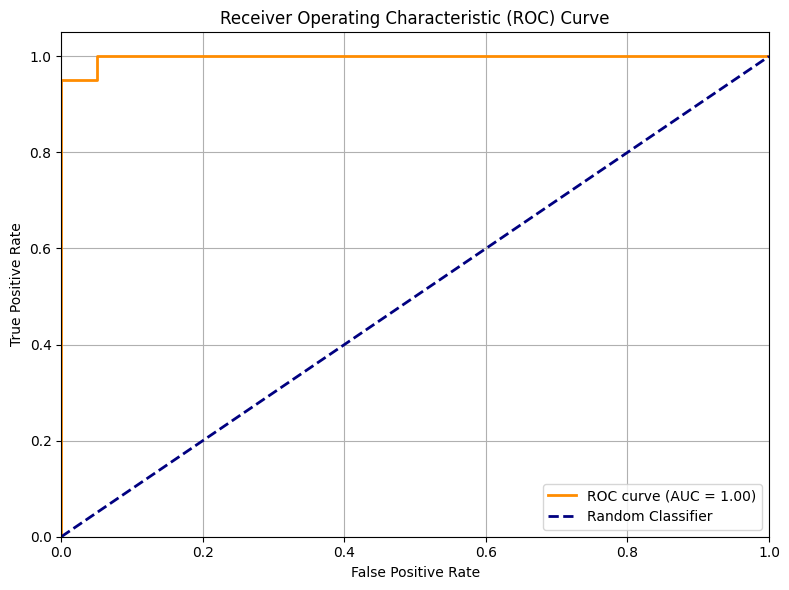

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get predicted probabilities for the positive class (good squats = 1)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Calculate AUC score
roc_auc = roc_auc_score(y_test, y_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# Interpretability: Feature Importance

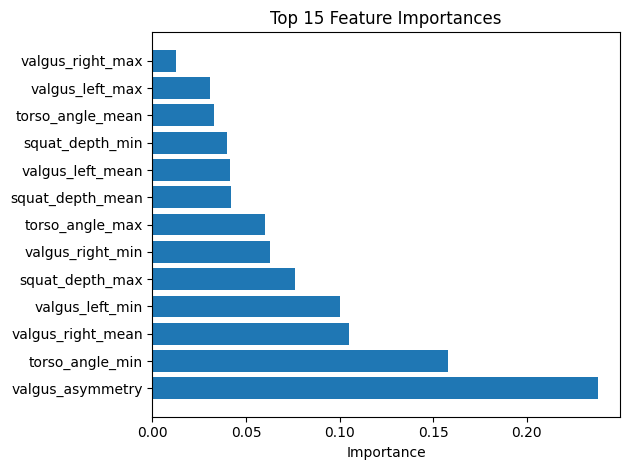

In [7]:
import matplotlib.pyplot as plt
importances = best_model.feature_importances_
feature_names = X.columns
sorted_idx = importances.argsort()[::-1]

plt.barh(feature_names[sorted_idx][:15], importances[sorted_idx][:15])
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
